<a href="https://colab.research.google.com/github/baaaRaathh/Natural-Language-Processing/blob/main/NLP(Consumer_Complaint_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
!ls /mydrive

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
'8 Sem Marksheet.jpeg'			        IMG_20221206_221519_126.jpg
'archive (7).zip'			        IMG_20221211_114412_163.jpg
 audio_tests.txt			        IMG_20221223_135900_364.jpg
 audio-utterances-3s.txt		        IMG_20230102_232317_996.jpg
'Barath Analyst.pdf'			        IMG_20230107_105458_039.jpg
'barath .gdoc'				        IMG_20230107_105620_645.jpg
 BarathKumarSResume.gdoc		        IMG_20230117_173406_965.jpg
'barath Machine Learning.pdf'		        IMG_20230117_230955_776.jpg
"barath's resume.pdf"			        IMG_20230117_230955_825.jpg
 can.zip				        IMG_20230122_234928_456.jpg
'Colab Notebooks'			        IMG_20230122_235156_068.jpg
 Consumer_Complaints.csv		        IMG_20230423_094226_853.jpg
'Copy of barath Machine Learning.pdf'	        IMG_20230423_094642_818.jpg
 database.sqlite			      

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Consumer_Complaints.csv')

In [ ]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer Complaint,Company Public Response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Sent to Company,Company Response to Consumer,Timely response?,Consumer disputed?,Complaint ID,Unnamed: 18
0,03-12-2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,03/17/2014,Closed with explanation,Yes,No,759217,NaN
1,10-01-2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10-05-2016,Closed with explanation,Yes,No,2141773,NaN
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100,NaN
3,06-08-2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,06-10-2014,Closed with explanation,Yes,Yes,885638,NaN
4,09/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,09/13/2014,Closed with explanation,Yes,Yes,1027760,NaN


In [ ]:
data=df[['Product','Consumer Complaint']]

In [ ]:
data=data[data['Consumer Complaint'].notnull()]

In [ ]:
data['Consumer Complaint'].loc[1025002]

'Our son was taken to XXXX XXXX XXXX XXXX XXXX XXXX on XXXX XXXX, 2012 as an ER visit. We had insurance through XXXX XXXX at the time and the hospital failed to submit the claim to our insurance company, and has been asking us to pay out of pocket for the services even though the services were covered under our insurance. XXXX says they submitted a claim for {$1200.00} to the insurance company, and when I asked XXXX to explain to me why it was denied, they could n\'t provide a reason other than simply saying that it " was n\'t paid \'\' ; I believe it " was n\'t paid \'\' because it was never sent out not to mention that XXXX has no record of this claim amount for XXXX 2012 for our son. \n\nMy husband I followed up numerous times with the hospital asking them to resubmit the appropriate paperwork to the insurance and they never sent the claim to the insurance, even though they reassured us they had. We tried everything possible to get the XXXX parties connected and appropriate document

In [ ]:
data = data.rename(columns={'Consumer Complaint':'Consumer_Complaint'})

In [ ]:
data.groupby('Product').Consumer_Complaint.count()

,Consumer_Complaint
Product,
Bank account or service,14887
Checking or savings account,6489
Consumer Loan,9474
Credit card,18842
Credit card or prepaid card,10659
Credit reporting,31593
"Credit reporting, credit repair services, or other personal consumer reports",49006
Debt collection,63268
"Money transfer, virtual currency, or money service",3089


In [ ]:
import matplotlib.pyplot as plt

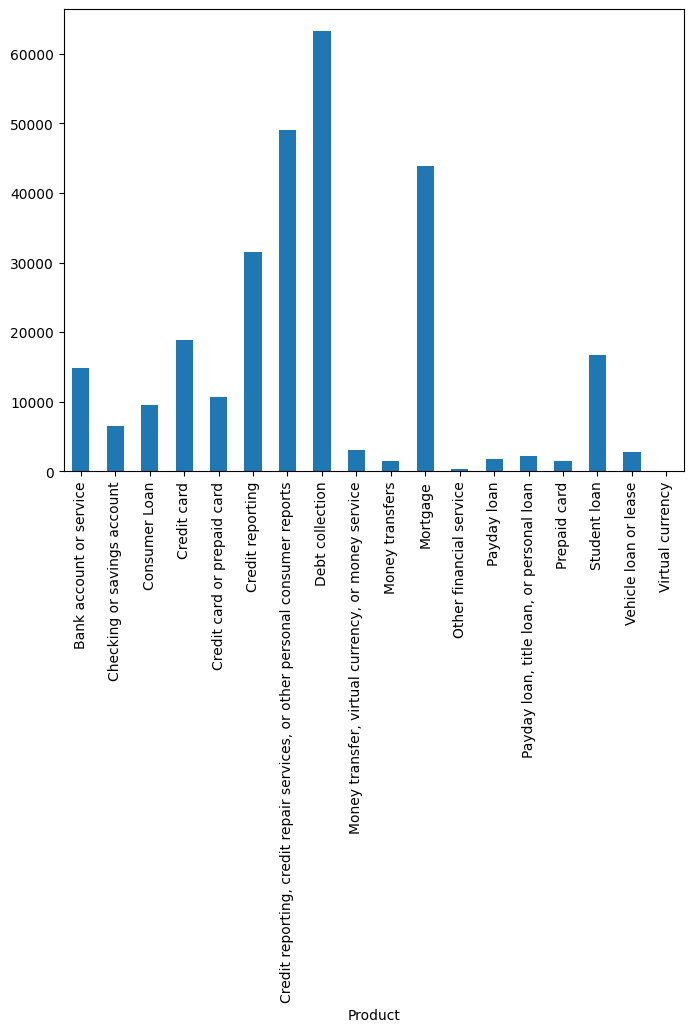

In [ ]:
fig = plt.figure(figsize=(8,6))
data.groupby('Product').Consumer_Complaint.count().plot.bar(ylim=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(data['Consumer_Complaint'],data['Product'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [ ]:
le = LabelEncoder()
ytrain = le.fit_transform(y_train)
ytest = le.fit_transform(y_test)
tf = TfidfVectorizer(analyzer='word',token_pattern=r"\w{1,}",max_features=5000)
tf.fit(data['Consumer_Complaint'])
xtrain = tf.transform(x_train)
xtest = tf.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
def train_model(classifier,x_trainn,y_trainn,x_tests,is_nureal_net=False):
  model = classifier.fit(x_trainn,y_trainn)
  pre = model.predict(x_tests)
  return accuracy_score(pre,ytest)

In [ ]:
# Logisitic regression mode
log = LogisticRegression()
ac = train_model(log,xtrain,ytrain,xtest)
print('Accuracy :',ac)

In [ ]:
#train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
acc = train_model(knn,xtrain,ytrain,xtest)
print('Accuracy :',acc)

Accuracy : 0.6354853572148472


In [ ]:
rf = RandomForestClassifier(random_state = 55,n_jobs=-1)
acc = rf.fit(xtrain,ytrain)


In [ ]:
pre = acc.predict(x_test)

In [ ]:
le = LabelEncoder()
le.fit(data['Product'].unique())
pro = le.transform(data['Product'].unique())
print("Encoder label :",pro)
de = le.inverse_transform(pro)
print("Decoder : ",de)

Encoder label : [ 5  2  7 10  3 11  0 15  9 12 14  8  6  1 16  4 17 13]
Decoder :  ['Credit reporting' 'Consumer Loan' 'Debt collection' 'Mortgage'
 'Credit card' 'Other financial service' 'Bank account or service'
 'Student loan' 'Money transfers' 'Payday loan' 'Prepaid card'
 'Money transfer, virtual currency, or money service'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Checking or savings account' 'Vehicle loan or lease'
 'Credit card or prepaid card' 'Virtual currency'
 'Payday loan, title loan, or personal loan']
